In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.decomposition import PCA

# Results from featurecloud kmeans 

## Load Data

In [62]:
k = 2
clients = 7

label_list = []
silhouette_list = []
clusterslabel_list = []
for client in range(clients):
    c = client + 1 
    label_list.append(pd.read_csv(f'data/client{c}/data/realmetadata.csv', sep=";")["Conditions"])
    silhouette_list.append(pd.read_csv(f'data/tests/results/K_{k}c{c}/silhouette.csv', sep=";", index_col=0))
    clusterslabel_list.append(pd.read_csv(f'data/tests/results/K_{k}c{c}/clustering.csv', sep=";", index_col=0))

all_true_label = pd.concat(label_list, ignore_index=True)
silhouette = pd.concat(silhouette_list, ignore_index=True)
all_predict = pd.concat(clusterslabel_list, ignore_index=True)

cluster = pd.read_csv(f'data/tests/results/K_{k}c1/centroids.csv', sep=";", index_col=0)

### Silhoute: How clear are the clusters seperated?
print('Silhoutte - mean: ')
print(silhouette.mean())

df_comparison = pd.concat([all_predict, all_true_label], ignore_index=True, axis=1)

Silhoutte - mean: 
0    0.393015
dtype: float64


In [63]:
def classify(true_labels, true_numeric, pred): 
    class_labels = np.unique(true_numeric)
    print(accuracy_score(true_numeric, pred))
    print(classification_report(true_numeric, pred))
    cm = confusion_matrix(y_pred=pred, y_true=true_numeric, labels=class_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

## Classification of featurecloud kmeans (Plot not possible)

0.6574074074074074
              precision    recall  f1-score   support

           0       1.00      0.56      0.72        85
           1       0.38      1.00      0.55        23

    accuracy                           0.66       108
   macro avg       0.69      0.78      0.64       108
weighted avg       0.87      0.66      0.69       108



C:\Users\piako\AppData\Local\Temp\ipykernel_28484\1005382030.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  all_predict = all_predict[~all_true_label.isin([" Not Reported", "Ovarian Tumor Sample"])]


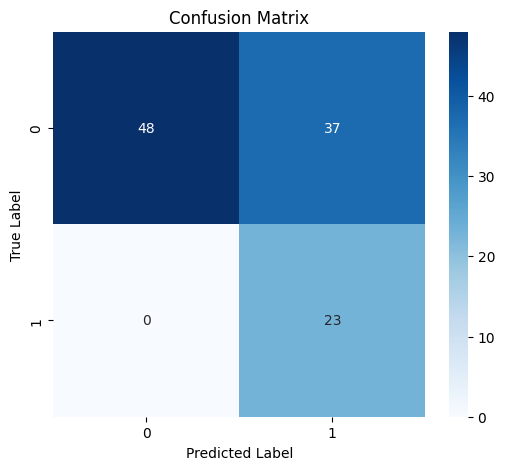

In [65]:
if k==4:
    label_mapping = {' Primary Tumor': 0, ' Solid Tissue Normal': 1, 'Ovarian Tumor Sample': 2, ' Not Reported': 3}
    class_labels = [0,1,2,3]
    true_labels = all_true_label
elif k==2: 
    label_mapping = {' Primary Tumor': 0, ' Solid Tissue Normal': 1}
    all_predict = all_predict[~all_true_label.isin([" Not Reported", "Ovarian Tumor Sample"])]
    true_labels = all_true_label[~all_true_label.isin([" Not Reported", "Ovarian Tumor Sample"])]
    class_labels = [0,1]
y_true_numeric = np.array([label_mapping[label] for label in true_labels])

classify(true_labels, y_true_numeric, all_predict)

#### -> K = 2 much better accuracy but only because many samples have tumor